In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [158]:
df = pd.read_csv("../data/raw/car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [159]:
print("Dataset shape:", df.shape)

Dataset shape: (301, 9)


In [160]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [162]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [163]:
missing_values = df.isnull().sum()

print(missing_values)

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [164]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [165]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 2


In [166]:
duplicates = df[df.duplicated(keep=False)]

print("Number of duplicate rows:", df.duplicated().sum())
duplicates

Number of duplicate rows: 2


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [167]:
# Remove exact duplicate rows from the dataset
# reset_index() creates a clean sequential index after removing the rows
df = df.drop_duplicates().reset_index(drop=True)

In [168]:
# Verify that all duplicate rows have been removed
remaining_duplicates = df.duplicated().sum()

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", remaining_duplicates)

Dataset shape after removing duplicates: (299, 9)
Remaining duplicate rows: 0


In [169]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [170]:
# Calculate the total number of missing values across the entire dataset
total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)


Total missing values: 0


In [171]:
# Define the categorical columns in the dataset
categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

# Display the unique values and their frequencies for each categorical column
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Fuel_Type ---
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

--- Seller_Type ---
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

--- Transmission ---
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [172]:
# Count the number of observations for each fuel type
fuel_counts = df["Fuel_Type"].value_counts()

print(fuel_counts)

# Calculate the percentage of the dataset represented by CNG
cng_count = (df["Fuel_Type"] == "CNG").sum()
cng_percentage = (cng_count / len(df)) * 100

print(f"\nNumber of CNG observations: {cng_count}")
print(f"Percentage of CNG observations: {cng_percentage:.2f}%")

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Number of CNG observations: 2
Percentage of CNG observations: 0.67%


In [173]:
# Group the rare CNG category with Petrol because there are too few CNG
# observations to reliably estimate an independent categorical effect
df["Fuel_Type"] = df["Fuel_Type"].replace("CNG", "Petrol")

In [174]:
# Verify the fuel categories after handling the rare CNG category
print(df["Fuel_Type"].value_counts())

Fuel_Type
Petrol    241
Diesel     58
Name: count, dtype: int64


In [175]:
# Define the categorical columns that need to be checked
# before we perform any transformations or feature engineering
categorical_columns = [
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

# Display each categorical column's unique values and
# the number of observations belonging to each category
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Fuel_Type ---
Fuel_Type
Petrol    241
Diesel     58
Name: count, dtype: int64

--- Seller_Type ---
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

--- Transmission ---
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [176]:
# Count the number of CNG observations in the cleaned dataset
# This confirms whether the rare CNG category still exists after duplicate removal
cng_count = (df["Fuel_Type"] == "CNG").sum()

# Calculate the percentage of the dataset represented by CNG
cng_percentage = (cng_count / len(df)) * 100

# Display the CNG count and percentage
print("Number of CNG observations:", cng_count)
print(f"Percentage of CNG observations: {cng_percentage:.2f}%")

Number of CNG observations: 0
Percentage of CNG observations: 0.00%


In [177]:
# Define the numerical columns that should contain numeric values
numerical_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner"
]

# Display the data type of each numerical column
print("Data types of numerical columns:")
print(df[numerical_columns].dtypes)

# Check whether any missing values exist in the numerical columns
print("\nMissing values:")
print(df[numerical_columns].isnull().sum())

# Display basic statistical information to identify
# unusual values or potential data-quality problems
print("\nSummary statistics:")
print(df[numerical_columns].describe())

Data types of numerical columns:
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Owner              int64
dtype: object

Missing values:
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Owner            0
dtype: int64

Summary statistics:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   299.000000     299.000000     299.000000     299.000000  299.000000
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478
std       2.896868       4.984240       8.567887   39015.170352    0.248720
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.00000

In [178]:
# Define the reference year using the latest year present in the dataset
# This converts the original Year variable into a more meaningful vehicle-age feature
reference_year = df["Year"].max()

# Calculate how old each car was relative to the latest year in the dataset
df["Car_Age"] = reference_year - df["Year"]

# Display the reference year and the first few calculated car ages
print("Reference year:", reference_year)
print("\nCar age examples:")
print(df[["Year", "Car_Age"]].head())

# Verify the range of the newly created Car_Age feature
print("\nCar_Age statistics:")
print(df["Car_Age"].describe())

Reference year: 2018

Car age examples:
   Year  Car_Age
0  2014        4
1  2013        5
2  2017        1
3  2011        7
4  2014        4

Car_Age statistics:
count    299.000000
mean       4.384615
std        2.896868
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       15.000000
Name: Car_Age, dtype: float64


In [179]:
# Display the first 20 car names to inspect their formatting
# before extracting the manufacturer/brand
print(df["Car_Name"].head(20).to_list())

['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza', 'ciaz', 's cross', 'ciaz', 'ciaz', 'alto 800', 'ciaz', 'ciaz', 'ertiga', 'dzire', 'ertiga', 'ertiga', 'wagon r', 'sx4', 'alto k10']


In [180]:
# Display all unique car names in the dataset
# This allows us to identify the different models before mapping
# each model to its manufacturer/brand
unique_car_names = sorted(df["Car_Name"].unique())

print("Number of unique car names:", len(unique_car_names))
print("\nUnique car names:")
print(unique_car_names)

Number of unique car names: 98

Unique car names:
['800', 'Activa 3g', 'Activa 4g', 'Bajaj  ct 100', 'Bajaj Avenger 150', 'Bajaj Avenger 150 street', 'Bajaj Avenger 220', 'Bajaj Avenger 220 dtsi', 'Bajaj Avenger Street 220', 'Bajaj Discover 100', 'Bajaj Discover 125', 'Bajaj Dominar 400', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 135 LS', 'Bajaj Pulsar 150', 'Bajaj Pulsar 220 F', 'Bajaj Pulsar NS 200', 'Bajaj Pulsar RS200', 'Hero  CBZ Xtreme', 'Hero  Ignitor Disc', 'Hero Extreme', 'Hero Glamour', 'Hero Honda CBZ extreme', 'Hero Honda Passion Pro', 'Hero Hunk', 'Hero Passion Pro', 'Hero Passion X pro', 'Hero Splender Plus', 'Hero Splender iSmart', 'Hero Super Splendor', 'Honda Activa 125', 'Honda Activa 4G', 'Honda CB Hornet 160R', 'Honda CB Shine', 'Honda CB Trigger', 'Honda CB Unicorn', 'Honda CB twister', 'Honda CBR 150', 'Honda Dream Yuga ', 'Honda Karizma', 'Hyosung GT250R', 'KTM 390 Duke ', 'KTM RC200', 'KTM RC390', 'Mahindra Mojo XT300', 'Royal Enfield Bullet 350', 'Royal Enfield Cla

In [181]:
# Create a mapping from each car model to its manufacturer/brand.
# Some car names already contain the brand, while others only contain
# the model name, so explicit mapping is safer and more reliable.

brand_mapping = {
    # Maruti Suzuki models
    "800": "Maruti",
    "alto 800": "Maruti",
    "alto k10": "Maruti",
    "baleno": "Maruti",
    "ciaz": "Maruti",
    "dzire": "Maruti",
    "ertiga": "Maruti",
    "ignis": "Maruti",
    "omni": "Maruti",
    "ritz": "Maruti",
    "s cross": "Maruti",
    "swift": "Maruti",
    "sx4": "Maruti",
    "vitara brezza": "Maruti",
    "wagon r": "Maruti",

    # Hyundai models
    "amaze": "Honda",
    "creta": "Hyundai",
    "elantra": "Hyundai",
    "eon": "Hyundai",
    "grand i10": "Hyundai",
    "i10": "Hyundai",
    "i20": "Hyundai",
    "verna": "Hyundai",
    "xcent": "Hyundai",

    # Toyota models
    "camry": "Toyota",
    "corolla": "Toyota",
    "corolla altis": "Toyota",
    "etios cross": "Toyota",
    "etios g": "Toyota",
    "etios gd": "Toyota",
    "etios liva": "Toyota",
    "fortuner": "Toyota",
    "innova": "Toyota",
    "land cruiser": "Toyota",

    # Honda models
    "brio": "Honda",
    "city": "Honda",
    "jazz": "Honda",

    # Explicitly branded motorcycles/scooters
    "Activa 3g": "Honda",
    "Activa 4g": "Honda",
    "Honda Activa 125": "Honda",
    "Honda Activa 4G": "Honda",
    "Honda CB Hornet 160R": "Honda",
    "Honda CB Shine": "Honda",
    "Honda CB Trigger": "Honda",
    "Honda CB Unicorn": "Honda",
    "Honda CB twister": "Honda",
    "Honda CBR 150": "Honda",
    "Honda Dream Yuga ": "Honda",
    "Honda Karizma": "Honda",

    "Bajaj  ct 100": "Bajaj",
    "Bajaj Avenger 150": "Bajaj",
    "Bajaj Avenger 150 street": "Bajaj",
    "Bajaj Avenger 220": "Bajaj",
    "Bajaj Avenger 220 dtsi": "Bajaj",
    "Bajaj Avenger Street 220": "Bajaj",
    "Bajaj Discover 100": "Bajaj",
    "Bajaj Discover 125": "Bajaj",
    "Bajaj Dominar 400": "Bajaj",
    "Bajaj Pulsar  NS 200": "Bajaj",
    "Bajaj Pulsar 135 LS": "Bajaj",
    "Bajaj Pulsar 150": "Bajaj",
    "Bajaj Pulsar 220 F": "Bajaj",
    "Bajaj Pulsar NS 200": "Bajaj",
    "Bajaj Pulsar RS200": "Bajaj",

    "Hero  CBZ Xtreme": "Hero",
    "Hero  Ignitor Disc": "Hero",
    "Hero Extreme": "Hero",
    "Hero Glamour": "Hero",
    "Hero Honda CBZ extreme": "Hero",
    "Hero Honda Passion Pro": "Hero",
    "Hero Hunk": "Hero",
    "Hero Passion Pro": "Hero",
    "Hero Passion X pro": "Hero",
    "Hero Splender Plus": "Hero",
    "Hero Splender iSmart": "Hero",
    "Hero Super Splendor": "Hero",

    "Hyosung GT250R": "Hyosung",
    "KTM 390 Duke ": "KTM",
    "KTM RC200": "KTM",
    "KTM RC390": "KTM",
    "Mahindra Mojo XT300": "Mahindra",

    "Royal Enfield Bullet 350": "Royal Enfield",
    "Royal Enfield Classic 350": "Royal Enfield",
    "Royal Enfield Classic 500": "Royal Enfield",
    "Royal Enfield Thunder 350": "Royal Enfield",
    "Royal Enfield Thunder 500": "Royal Enfield",

    "Suzuki Access 125": "Suzuki",

    "TVS Apache RTR 160": "TVS",
    "TVS Apache RTR 180": "TVS",
    "TVS Jupyter": "TVS",
    "TVS Sport ": "TVS",
    "TVS Wego": "TVS",

    "UM Renegade Mojave": "UM",
    "Yamaha FZ  v 2.0": "Yamaha",
    "Yamaha FZ 16": "Yamaha",
    "Yamaha FZ S ": "Yamaha",
    "Yamaha FZ S V 2.0": "Yamaha",
    "Yamaha Fazer ": "Yamaha"
}

# Create the Brand feature by mapping each car name to its manufacturer
df["Brand"] = df["Car_Name"].map(brand_mapping)

# Check whether any car names failed to receive a brand
unmapped_count = df["Brand"].isnull().sum()

print("Number of unmapped car names:", unmapped_count)

# Display the number of observations for each resulting brand
print("\nBrand distribution:")
print(df["Brand"].value_counts())

Number of unmapped car names: 0

Brand distribution:
Brand
Honda            70
Hyundai          50
Maruti           49
Toyota           49
Bajaj            25
Royal Enfield    17
Hero             15
Yamaha            8
TVS               8
KTM               4
UM                1
Hyosung           1
Mahindra          1
Suzuki            1
Name: count, dtype: int64


In [182]:
# Define which brands/models represent motorcycles or scooters.
# Vehicle type is added explicitly because cars and motorcycles
# have different price ranges and depreciation patterns.

motorcycle_brands = [
    "Bajaj",
    "Hero",
    "KTM",
    "Royal Enfield",
    "TVS",
    "Yamaha",
    "Hyosung",
    "Mahindra",
    "UM",
    "Suzuki"
]

# Start by classifying vehicles based on brands that are exclusively
# represented by motorcycles/scooters in this dataset.
df["Vehicle_Type"] = np.where(
    df["Brand"].isin(motorcycle_brands),
    "Motorcycle",
    "Car"
)

# Honda requires special handling because the dataset contains
# both Honda cars and Honda motorcycles/scooters.
honda_motorcycle_keywords = [
    "Activa",
    "CB ",
    "CBR ",
    "Dream",
    "Karizma"
]

# Reclassify Honda models that are explicitly motorcycles/scooters.
honda_mask = (
    (df["Brand"] == "Honda") &
    (df["Car_Name"].apply(
        lambda name: any(keyword in name for keyword in honda_motorcycle_keywords)
    ))
)

df.loc[honda_mask, "Vehicle_Type"] = "Motorcycle"

# Display the resulting vehicle-type distribution.
print("Vehicle Type distribution:")
print(df["Vehicle_Type"].value_counts())

# Display Honda classifications to verify that both cars and motorcycles
# have been handled correctly.
print("\nHonda vehicle classification:")
print(
    df.loc[df["Brand"] == "Honda", ["Car_Name", "Brand", "Vehicle_Type"]]
    .sort_values("Car_Name")
)

Vehicle Type distribution:
Vehicle_Type
Car           198
Motorcycle    101
Name: count, dtype: int64

Honda vehicle classification:
             Car_Name  Brand Vehicle_Type
163         Activa 3g  Honda   Motorcycle
194         Activa 3g  Honda   Motorcycle
171         Activa 4g  Honda   Motorcycle
175  Honda Activa 125  Honda   Motorcycle
153   Honda Activa 4G  Honda   Motorcycle
..                ...    ...          ...
271              jazz  Honda          Car
276              jazz  Honda          Car
283              jazz  Honda          Car
284              jazz  Honda          Car
290              jazz  Honda          Car

[70 rows x 3 columns]


In [183]:
# Calculate the ratio between the current selling price and
# the original/present price of the car.
# This feature is useful for EDA to study depreciation.
# IMPORTANT: Price_Ratio contains Selling_Price, so it must NOT
# be used as a feature when training the machine learning models.
df["Price_Ratio"] = df["Selling_Price"] / df["Present_Price"]

# Display the first few rows to verify the calculation
print("Price_Ratio examples:")
print(df[["Selling_Price", "Present_Price", "Price_Ratio"]].head())

# Display summary statistics to understand the distribution
print("\nPrice_Ratio statistics:")
print(df["Price_Ratio"].describe())

Price_Ratio examples:
   Selling_Price  Present_Price  Price_Ratio
0           3.35           5.59     0.599284
1           4.75           9.54     0.497904
2           7.25           9.85     0.736041
3           2.85           4.15     0.686747
4           4.60           6.87     0.669578

Price_Ratio statistics:
count    299.000000
mean       0.633780
std        0.202875
min        0.105352
25%        0.505051
50%        0.654255
75%        0.790624
max        0.989255
Name: Price_Ratio, dtype: float64


In [184]:
# Select the numerical features that will be examined for skewness.
# Price_Ratio is included because it is useful for EDA, even though
# it will not be used as a machine learning feature.
skewness_columns = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Price_Ratio"
]

# Calculate the skewness of each numerical variable.
# Positive values indicate right-skewness, while negative values
# indicate left-skewness.
skewness = df[skewness_columns].skew().sort_values(ascending=False)

# Display the skewness values.
print("Skewness of numerical variables:")
print(skewness)

Skewness of numerical variables:
Kms_Driven       6.418134
Present_Price    4.186894
Selling_Price    2.536522
Car_Age          1.236876
Price_Ratio     -0.383196
dtype: float64


In [185]:
# Display the final dataset shape after cleaning and feature engineering
print("Final dataset shape:", df.shape)

# Check that no missing values were introduced during feature engineering
print("\nMissing values:")
print(df.isnull().sum())

# Check that no duplicate rows were introduced
print("\nDuplicate rows:", df.duplicated().sum())

# Verify that the important engineered columns exist
required_columns = [
    "Car_Name",
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Car_Age",
    "Brand",
    "Vehicle_Type",
    "Price_Ratio"
]

# Identify any expected columns that are missing
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

print("\nMissing required columns:", missing_columns)

# Display the final column names for a quick structural check
print("\nFinal columns:")
print(df.columns.tolist())

Final dataset shape: (299, 13)

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_Age          0
Brand            0
Vehicle_Type     0
Price_Ratio      0
dtype: int64

Duplicate rows: 0

Missing required columns: []

Final columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Brand', 'Vehicle_Type', 'Price_Ratio']


In [186]:
# Define the path where the cleaned and feature-engineered dataset will be saved
output_path = "../data/processed/processed_car_data.csv"

# Save the processed dataframe without writing the Pandas index
# so the CSV contains only the actual dataset columns
df.to_csv(output_path, index=False)

# Confirm that the processed dataset has been saved successfully
print("Processed dataset saved to:", output_path)

Processed dataset saved to: ../data/processed/processed_car_data.csv


## Data Cleaning & Feature Engineering

The dataset was cleaned and prepared for the machine learning workflow.

- Removed **2 exact duplicate rows**, reducing the dataset from 301 to **299 observations**.
- Confirmed **no missing values** were present.
- Validated numerical columns and confirmed appropriate numeric data types.
- Validated categorical variables (`Fuel_Type`, `Seller_Type`, and `Transmission`).
- Confirmed that there were **no CNG observations** after duplicate removal, so no category grouping was required.
- Created `Car_Age` using 2018, the latest year in the dataset, as the reference year.
- Created a `Brand` feature by mapping the 98 unique car models to their manufacturers. All observations were successfully mapped.
- Created `Price_Ratio` for exploratory analysis only. It will **not** be used for model training because it contains the target variable `Selling_Price` and would cause target leakage.
- Examined numerical feature skewness. Strong right-skew was observed in `Kms_Driven`, `Present_Price`, and `Selling_Price`; no transformation was applied at this stage.
Created a Vehicle_Type feature to explicitly distinguish cars from motorcycles/scooters. This prevents the model from having to infer vehicle type indirectly from brand and price-related variables.
- Performed final validation and saved the processed dataset as:

`data/processed/processed_car_data.csv`

The resulting dataset contains **299 rows and 13 columns** and is ready for exploratory data analysis.

In [187]:
# Import the libraries needed for EDA and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the processed dataset created on Day 1
df = pd.read_csv("../data/processed/processed_car_data.csv")

# Create the figures directory if it does not already exist
os.makedirs("../outputs/figures", exist_ok=True)

# Confirm that the directory is ready
print("EDA figures directory is ready.")

EDA figures directory is ready.


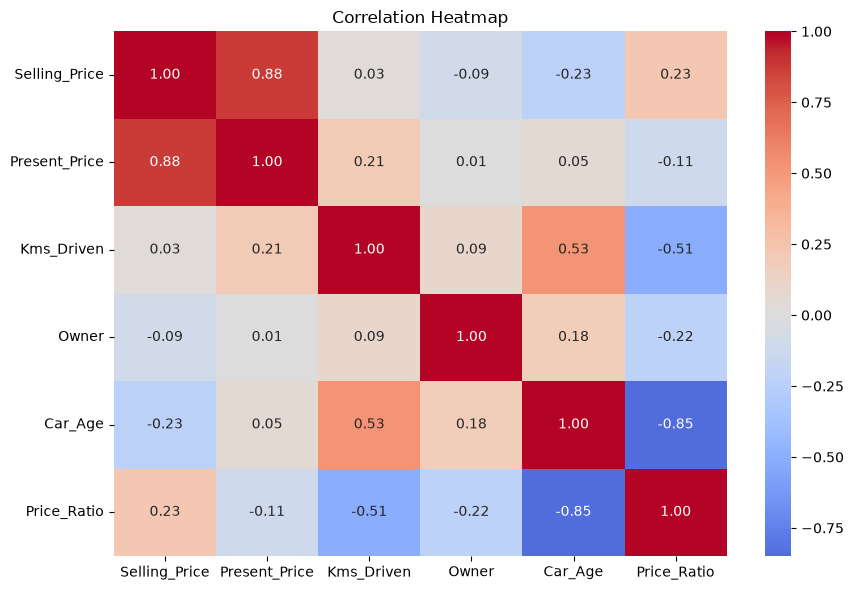

In [188]:
# Select numerical variables for correlation analysis
correlation_columns = [
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
    "Price_Ratio"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Create the correlation heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

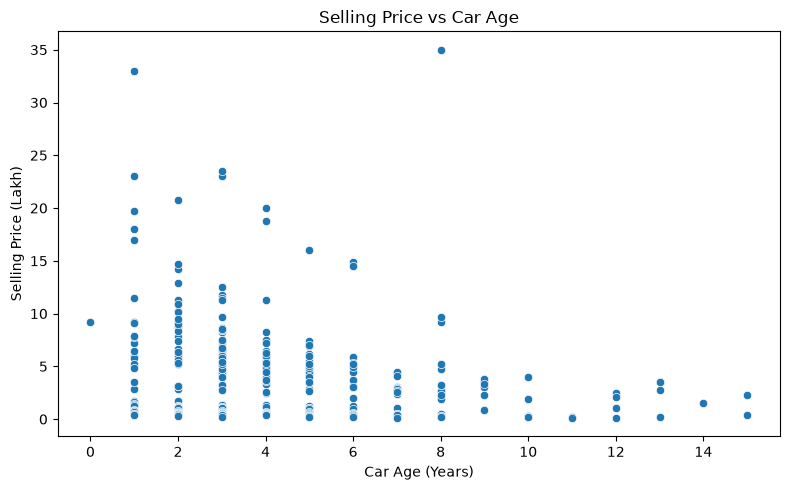

In [189]:
# Create a scatter plot to examine how vehicle age relates to selling price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/selling_price_vs_car_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

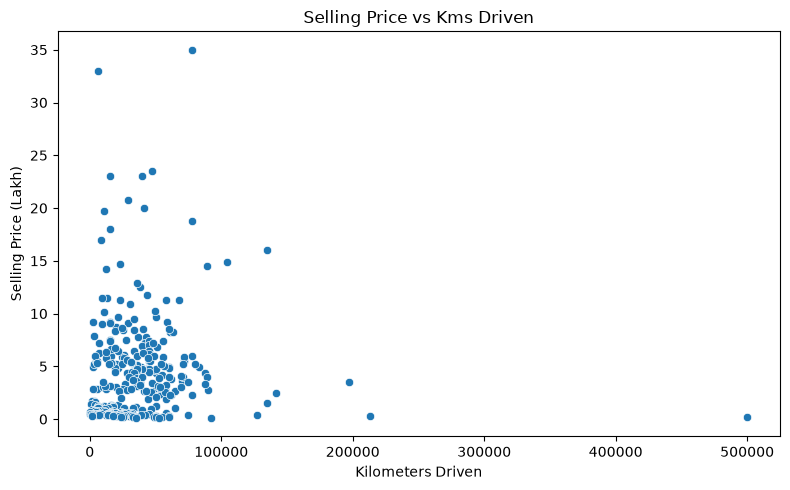

In [190]:
# Create a scatter plot to examine the relationship between
# mileage and selling price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.title("Selling Price vs Kms Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/selling_price_vs_kms_driven.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

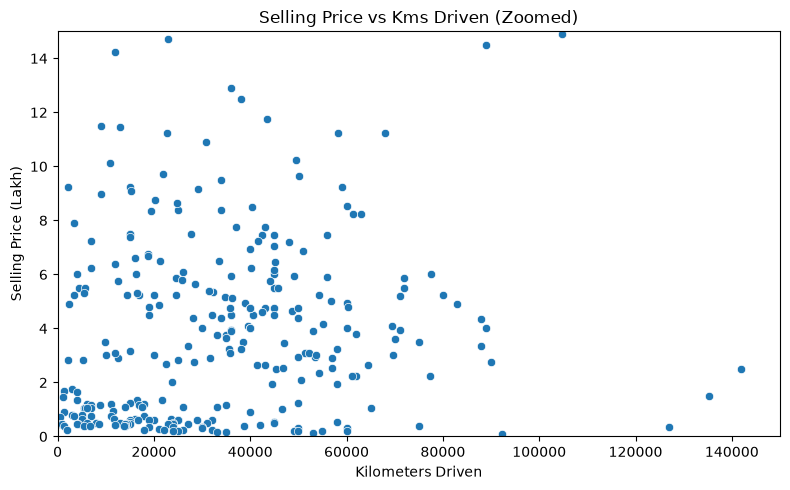

In [191]:
# Create a zoomed scatter plot to better visualize the majority
# of observations while keeping the original data unchanged
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Kms_Driven",
    y="Selling_Price"
)

# Limit the axes to the main concentration of observations
# This is only for visualization and does not modify the dataset
plt.xlim(0, 150000)
plt.ylim(0, 15)

plt.title("Selling Price vs Kms Driven (Zoomed)")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()

# Save the zoomed visualization
plt.savefig(
    "../outputs/figures/selling_price_vs_kms_driven_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

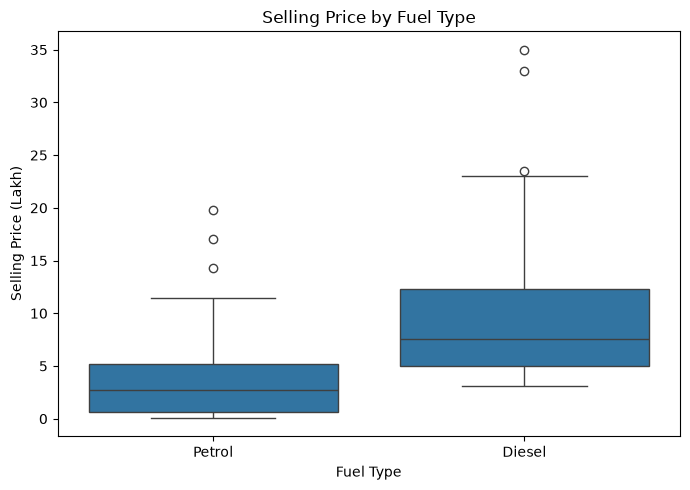

In [192]:
# Create a boxplot to compare the distribution of selling prices
# between Petrol and Diesel vehicles
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/selling_price_by_fuel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

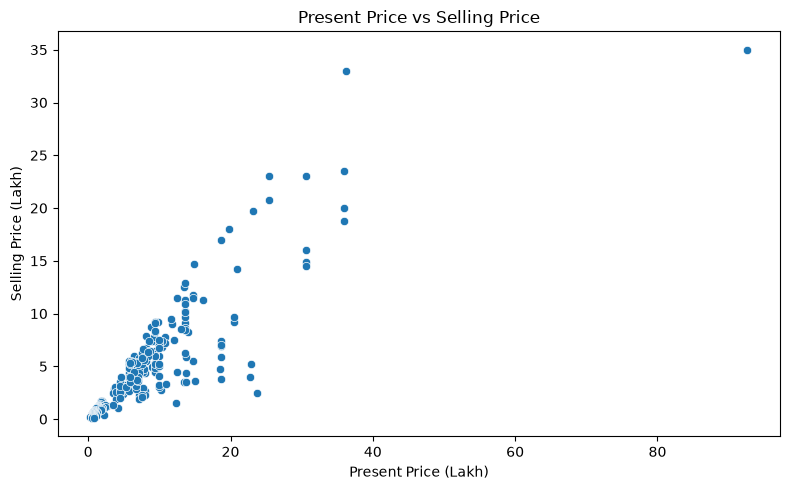

In [193]:
# Create a scatter plot to examine the relationship between
# present market price and selling price
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakh)")
plt.ylabel("Selling Price (Lakh)")
plt.tight_layout()

# Save the figure
plt.savefig(
    "../outputs/figures/present_price_vs_selling_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [194]:
# Display correlations between the target and the main numerical variables
print("Correlation with Selling_Price:")
print(
    correlation_matrix["Selling_Price"]
    .sort_values(ascending=False)
)

# Compare selling prices across fuel types
print("\nSelling Price by Fuel Type:")
print(
    df.groupby("Fuel_Type")["Selling_Price"]
    .agg(["count", "mean", "median"])
)

# Display average selling price by brand, keeping only brands
# with at least five observations to avoid over-interpreting tiny groups
brand_summary = (
    df.groupby("Brand")["Selling_Price"]
    .agg(["count", "mean", "median"])
)

brand_summary = brand_summary[
    brand_summary["count"] >= 5
].sort_values("mean", ascending=False)

print("\nSelling Price by Brand:")
print(brand_summary)

Correlation with Selling_Price:
Selling_Price    1.000000
Present_Price    0.876378
Price_Ratio      0.230115
Kms_Driven       0.028566
Owner           -0.087880
Car_Age         -0.234369
Name: Selling_Price, dtype: float64

Selling Price by Fuel Type:
           count       mean  median
Fuel_Type                          
Diesel        58  10.102759     7.6
Petrol       241   3.262822     2.7

Selling Price by Brand:
               count       mean  median
Brand                                  
Toyota            49  10.157551   5.850
Hyundai           50   5.483200   5.030
Maruti            49   4.591837   4.600
Honda             70   4.559571   4.650
Royal Enfield     17   1.144706   1.100
Yamaha             8   0.582500   0.575
Bajaj             25   0.528000   0.500
TVS                8   0.462500   0.465
Hero              15   0.362000   0.380


## — Exploratory Data Analysis

The exploratory analysis revealed several important patterns in the dataset:

- `Present_Price` has a **strong positive relationship** with `Selling_Price` (correlation ≈ **0.88**), making it the strongest numerical indicator of resale price.
- `Car_Age` has a **negative relationship** with `Selling_Price` (correlation ≈ **-0.23**), indicating that older cars generally have lower resale values.
- `Kms_Driven` has almost **no linear correlation** with `Selling_Price` (correlation ≈ **0.03**). This suggests that mileage alone is not a strong linear predictor of price.
- Diesel vehicles have a substantially higher average selling price (**10.10 lakh**) than Petrol vehicles (**3.26 lakh**) in this dataset.
- Brand-level analysis shows considerable differences in average selling prices, with Toyota having the highest average among brands with at least five observations.
- The scatter plots show considerable variation in selling prices, indicating that vehicle price is influenced by multiple factors rather than a single variable.
- Several numerical variables are right-skewed, particularly `Kms_Driven`, `Present_Price`, and `Selling_Price`. Extreme observations were retained because they may represent legitimate vehicles rather than data errors.

### Selling Price by Fuel Type (Boxplot)

**Diesel cars sell for more, on average, than petrol cars.**

- **Median price:** Diesel (~7.5 Lakh) is noticeably higher than Petrol (~3 Lakh).
- **Spread (IQR):** Diesel prices are more spread out (~5–12 Lakh) compared to Petrol (~1–5 Lakh), meaning diesel cars vary more widely in price.
- **Outliers:**
  - Petrol has a few high-value outliers (~14–20 Lakh), likely premium/luxury petrol models.
  - Diesel has more extreme outliers (~23–35 Lakh), suggesting some very high-end diesel vehicles (likely SUVs or luxury cars).
- **Overall range:** Diesel cars occupy a higher price bracket overall, while petrol cars are concentrated at the lower end with only a few pricier exceptions.

**Takeaway:** Fuel type appears to be a meaningful factor in price — diesel vehicles tend to be pricier and show greater price variability, possibly because diesel engines are more common in higher-end or larger vehicles (SUVs, premium sedans).

### Overall Conclusion

The EDA suggests that **vehicle market price, age, fuel type, brand, and other vehicle characteristics should be considered together** when predicting `Selling_Price`.

`Price_Ratio` was used only for exploratory analysis and will be excluded from model training to prevent target leakage.

In [195]:
# Import the preprocessing tools needed for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the numerical features that will be scaled
numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Owner"
]

# Define the categorical features that will be one-hot encoded
categorical_features = [
    "Brand",
    "Vehicle_Type",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

# Create the preprocessing transformer.
# Each transformer is fitted only on the training data through the pipeline.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [196]:
# Define the target variable
target = "Selling_Price"

# Define the features used for prediction.
# Price_Ratio is excluded because it causes target leakage.
# Car_Name and Year are excluded because Brand and Car_Age already encode that information.
features = [
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Owner",
    "Brand",
    "Vehicle_Type",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

# Separate features from the target
X = df[features]
y = df[target]

# Split into training and testing sets.
# The same split is reused for every model to keep comparisons fair.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (239, 9), Test shape: (60, 9)


In [197]:
# Import the preprocessing tools needed for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the numerical features that will be scaled
numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Owner"
]

# Define the categorical features that will be one-hot encoded
categorical_features = [
    "Brand",
    "Vehicle_Type",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

# Create the preprocessing transformer.
# Each transformer is fitted only on the training data through the pipeline,
# which prevents information from the test set leaking into preprocessing.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [198]:
# Import the regression models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Baseline model: predicts the mean of the training target every time.
# Any useful model should clearly beat this.
dummy_model = DummyRegressor(strategy="mean")

# Simple linear regression as an interpretable baseline model
linear_model = LinearRegression()

# Lasso regression: linear model with L1 regularization,
# useful for slightly reducing overfitting and encouraging sparsity
lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Random Forest: non-linear ensemble model, generally robust on small tabular datasets
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# XGBoost: gradient boosting model, often strong on small/medium tabular data
xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    objective="reg:squarederror"
)

# Collect all models in a dictionary so they can be looped over
models = {
    "Dummy": dummy_model,
    "LinearRegression": linear_model,
    "Lasso": lasso_model,
    "RandomForest": random_forest_model,
    "XGBoost": xgboost_model
}

In [199]:
# Import Pipeline to combine preprocessing and model training into one object
from sklearn.pipeline import Pipeline

# Store trained pipelines so they can be reused for evaluation later
trained_pipelines = {}

# Train every model using the exact same preprocessing pipeline and train split
for model_name, model in models.items():

    # Combine preprocessing and regression into one pipeline.
    # This guarantees preprocessing is refit correctly and consistently for each model.
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Fit only on the training data — the test set stays untouched until evaluation
    pipeline.fit(X_train, y_train)

    # Store the trained pipeline for later use
    trained_pipelines[model_name] = pipeline

    print(f"{model_name} trained successfully.")

Dummy trained successfully.
LinearRegression trained successfully.
Lasso trained successfully.
RandomForest trained successfully.
XGBoost trained successfully.


In [200]:
# Import metrics needed for regression evaluation
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store evaluation results for each model
results = []

for model_name, pipeline in trained_pipelines.items():

    # Generate predictions on the untouched test set
    y_pred = pipeline.predict(X_test)

    # Calculate the three key regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

# Build a single ranking table, sorted by RMSE (lower is better)
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,XGBoost,0.8319,1.8086,0.8731
1,Lasso,1.5213,2.6233,0.7330
2,LinearRegression,1.5723,2.7121,0.7146
3,RandomForest,1.4260,3.4805,0.5300
4,Dummy,3.3269,5.0768,-0.0000


In [201]:
# Identify the best model based on the ranking table (lowest RMSE)
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best model: {best_model_name}")

# Get the feature names AFTER one-hot encoding, so importances line up correctly
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
ohe_feature_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numerical_features, ohe_feature_names])

# Built-in feature importances (only meaningful for tree-based models like RF/XGBoost)
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    importances = best_pipeline.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
    print(importance_df.head(10))

# Permutation importance: model-agnostic, computed on the test set.
# More reliable than built-in importances since it reflects actual predictive contribution.
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=30, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
}).sort_values("Importance_Mean", ascending=False)

perm_df

Best model: XGBoost
                   Feature  Importance
0            Present_Price    0.766728
2                  Car_Age    0.130468
18        Fuel_Type_Diesel    0.063548
1               Kms_Driven    0.013702
7            Brand_Hyundai    0.012271
22  Transmission_Automatic    0.004606
6              Brand_Honda    0.003185
9             Brand_Maruti    0.002867
13            Brand_Toyota    0.002586
5               Brand_Hero    0.000041


,Feature,Importance_Mean,Importance_Std
0,Present_Price,1.420052,0.248392
2,Car_Age,0.226690,0.047892
1,Kms_Driven,0.077762,0.016285
6,Fuel_Type,0.041912,0.016508
4,Brand,0.002922,0.003065
8,Transmission,0.000989,0.000704
3,Owner,0.000000,0.000000
5,Vehicle_Type,0.000000,0.000000
7,Seller_Type,0.000000,0.000000


In [202]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define a focused hyperparameter grid for XGBoost.
# Kept relatively small since the dataset is only ~299 rows —
# a huge grid risks overfitting to noise in cross-validation folds.
param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Rebuild an untrained pipeline with the same preprocessor + a fresh XGBRegressor.
# Reusing the already-fitted trained_pipelines["XGBoost"] would risk leaking
# fitted state into the grid search, so we start clean.
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

# Set up grid search with 5-fold cross-validation.
# IMPORTANT: this only ever touches X_train / y_train — the test set stays untouched.
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search on training data only
grid_search.fit(X_train, y_train)

print("Best cross-validated RMSE:", -grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best cross-validated RMSE: 1.3181870029275995
Best parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.8}


In [203]:
# Get the best estimator found by grid search
best_xgb_pipeline = grid_search.best_estimator_

# Evaluate the tuned model on the held-out test set
y_pred_tuned = best_xgb_pipeline.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

# Pull the untuned XGBoost results from the earlier results_df for direct comparison
untuned_row = results_df[results_df["Model"] == "XGBoost"].iloc[0]

comparison_df = pd.DataFrame([
    {
        "Version": "XGBoost (untuned)",
        "MAE": untuned_row["MAE"],
        "RMSE": untuned_row["RMSE"],
        "R2": untuned_row["R2"]
    },
    {
        "Version": "XGBoost (tuned)",
        "MAE": round(mae_tuned, 4),
        "RMSE": round(rmse_tuned, 4),
        "R2": round(r2_tuned, 4)
    }
])

comparison_df

,Version,MAE,RMSE,R2
0,XGBoost (untuned),0.8319,1.8086,0.8731
1,XGBoost (tuned),0.7785,1.6508,0.8943


In [204]:
# Import joblib to save the trained pipeline and os to build file paths.
import joblib
import os

# Build the path to the project root because this notebook is inside the notebooks folder.
project_root = os.path.abspath("..")

# Define the top-level models directory.
models_dir = os.path.join(project_root, "models")

# Create the models directory if it does not already exist.
os.makedirs(models_dir, exist_ok=True)

# Define the final model path inside the project's top-level models folder.
model_path = os.path.join(models_dir, "car_price_model.pkl")

# Save the complete preprocessing + XGBoost pipeline.
joblib.dump(best_xgb_pipeline, model_path)

# Confirm exactly where the model was saved.
print("Model saved to:", model_path)

Model saved to: c:\Users\LENOVO\Documents\EXPS_car_price_prediction\models\car_price_model.pkl
